In [ ]:
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Configuration ─────────────────────────────────
import os, sys, random, warnings, hashlib, time, tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load
import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found.', ImportWarning)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATASET_PATH = os.environ.get('DATASET_PATH', '/dataset_encoded_normalized1.csv')

N_LAYERS    = 3
ENTANGLE    = 'circular'
DE_MAXITER  = 20
DE_POPSZ    = 10
N_SPLITS_CV = 5

CACHE_DIR = 'cache_hybrid_ensemble_final__pub'
os.makedirs(CACHE_DIR, exist_ok=True)
FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane : {qml.version()}  |  Python : {sys.version.split()[0]}')
print(f'Dataset   : {DATASET_PATH}')

PennyLane : 0.44.1  |  Python : 3.13.11
Dataset   : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv


In [ ]:
# ── Cell 3 : Data Loading & 3-Way Split (70 / 15 / 15) ────────────────────
assert os.path.exists(DATASET_PATH), f'Dataset not found: {DATASET_PATH}'
df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)
N_FEATURES = X_raw.shape[1]
n_qubits   = N_FEATURES

HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

X_tr_r, X_temp, Y_train, Y_temp = train_test_split(X_raw, Y, test_size=0.30, random_state=SEED)
X_val_r, X_test_r, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=SEED)

scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_tr_r)
X_val   = scaler.transform(X_val_r)
X_test  = scaler.transform(X_test_r)

X_trainval = np.vstack([X_train, X_val])
Y_trainval = np.concatenate([Y_train, Y_val])

print(f'Dataset  : {X_raw.shape[0]} × {N_FEATURES}  |  Hash: {HASH}')
print(f'Split    : Train={X_train.shape[0]}  Val={X_val.shape[0]}  Test={X_test.shape[0]}')
print(f'n_qubits : {n_qubits}  (hybrid encoding: amplitude + RX)')
print('X_test will be touched ONCE at the final evaluation cell.')

Dataset  : 13106 × 12  |  Hash: 8f057170
Split    : Train=9174  Val=1966  Test=1966
n_qubits : 12  (hybrid encoding: amplitude + RX)
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device ───────────────────────────────────────────
try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU ready: {n_qubits} qubits')
except Exception as e:
    warnings.warn(f'GPU unavailable ({e}). Falling back.', RuntimeWarning)
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'
dev_cpu = qml.device('default.qubit', wires=n_qubits)
print(f'Active: {DEVICE_LABEL}')

GPU ready: 12 qubits
Active: lightning.gpu


In [ ]:
# ── Cell 5 : Hybrid Circuit Factory ────────────────────────────────────
#
# FIX: QNode via factory (replaces _qnode_cache global hack from original).
# FIX: Parallel(loky) REMOVED — loky cannot share CUDA context.

def build_hybrid_circuit(device, topology='circular'):
    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        n_feat     = len(x)
        amp_qubits = min(n_qubits, max(1, int(np.ceil(np.log2(n_feat)))) if n_feat > 1 else 1)
        dim_amp    = 2 ** amp_qubits
        amp_feat   = (x[:dim_amp].tolist() if n_feat >= dim_amp
                      else x.tolist() + [0.0] * (dim_amp - n_feat))
        qml.AmplitudeEmbedding(features=amp_feat, wires=list(range(amp_qubits)), normalize=True)
        rotation_data = x[dim_amp:] if n_feat > dim_amp else np.array([])
        rot_wires     = list(range(amp_qubits, n_qubits))
        if rotation_data.size > 0 and rot_wires:
            for i, wire in enumerate(rot_wires):
                qml.RX(rotation_data[i % len(rotation_data)], wires=wire)
        elif rotation_data.size > 0:
            for i in range(n_qubits):
                qml.RX(rotation_data[i % len(rotation_data)], wires=i)
        for layer in range(weights.shape[0]):
            for i in range(n_qubits): qml.RY(weights[layer, i], wires=i)
            if topology == 'linear':
                for i in range(n_qubits-1): qml.CNOT(wires=[i, i+1])
            elif topology == 'circular':
                for i in range(n_qubits-1): qml.CNOT(wires=[i, i+1])
                if n_qubits > 1: qml.CNOT(wires=[n_qubits-1, 0])
            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i+1, n_qubits): qml.CNOT(wires=[i, j])
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Sequential GPU-safe feature map (no loky parallelism)."""
    n, out = len(X_data), []
    for idx, xi in enumerate(X_data):
        out.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx+1) % max(1, n//10) == 0:
            print(f'  {idx+1}/{n}')
    return np.array(out)


circuit_default = build_hybrid_circuit(dev_gpu, topology=ENTANGLE)
print(f'Hybrid circuit ready | {n_qubits} qubits | topology={ENTANGLE} | N_LAYERS={N_LAYERS}')

Hybrid circuit ready | 12 qubits | topology=circular | N_LAYERS=3


In [ ]:
# ── Cell 5b : Base Learner Definitions & Hyperparameter Grids ─────────────────
#
# FIX: BASE_LEARNERS, tuning grids, cache paths, LEARNER_COLORS, and
# tune_base_learner() were missing — causing NameError in Cell 6 and beyond.

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from joblib import dump, load

# ── Base learner registry (name → unfitted estimator) ─────────────────────────
BASE_LEARNERS = [
    ('dt',  DecisionTreeRegressor(random_state=SEED)),
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('mlp', Pipeline([('scaler', StandardScaler()),
                      ('mlp', MLPRegressor(max_iter=500, random_state=SEED))])),
]

# ── Hyperparameter search spaces ───────────────────────────────────────────────
DT_PARAMS = {
    'max_depth':        [None, 3, 5, 7, 10],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None],
}
RF_PARAMS = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2'],
}
MLP_PARAMS = {
    'mlp__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'mlp__alpha':              [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 5e-4, 1e-2],
    'mlp__activation':         ['relu', 'tanh'],
}

# ── Per-learner joblib cache paths ─────────────────────────────────────────────
DT_CACHE_BASE  = os.path.join(CACHE_DIR, 'tuned_dt.joblib')
RF_CACHE_BASE  = os.path.join(CACHE_DIR, 'tuned_rf.joblib')
MLP_CACHE_BASE = os.path.join(CACHE_DIR, 'tuned_mlp.joblib')

# ── Colours used in convergence & importance plots ────────────────────────────
LEARNER_COLORS = {'dt': '#2563EB', 'rf': '#16A34A', 'mlp': '#DC2626'}

# ── Generic tuning helper (RandomizedSearchCV, cv=5) ──────────────────────────
def tune_base_learner(estimator, param_dist, X_tr, Y_tr, label, cache_path, n_iter=20):
    if os.path.exists(cache_path):
        print(f"  [{label}] Tuned model loaded from cache: {cache_path}")
        return load(cache_path)
    print(f"  [{label}] Tuning with RandomizedSearchCV ({n_iter} iter, {N_SPLITS_CV}-fold)...")
    search = RandomizedSearchCV(
        estimator, param_dist,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_tr, Y_tr)
    best = search.best_estimator_
    dump(best, cache_path)
    print(f"  [{label}] Best params : {search.best_params_}")
    print(f"  [{label}] Best CV MSE : {-search.best_score_:.6f}")
    return best

print(f"BASE_LEARNERS defined : {[n for n,_ in BASE_LEARNERS]}")
print("Hyperparameter grids, cache paths, colours, and tune_base_learner() ready.")


BASE_LEARNERS defined : ['dt', 'rf', 'mlp']
Hyperparameter grids, cache paths, colours, and tune_base_learner() ready.


In [ ]:
from sklearn.tree import DecisionTreeRegressor
def _build_proxy_model():
    return DecisionTreeRegressor(max_depth=5, random_state=SEED)

# ── Cell 6 : COBYLA — Weight Optimization ─────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

call_counter = {'n': 0}


def make_objective(circuit_fn, n_lay, history):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None, history=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    if history is not None:
        history.clear()
    else:
        history = []

    obj = make_objective(circuit_fn, n_lay, history)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


# ── Optimization loop — one per base learner ──────────────────────────────────
print('Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...')
best_weights = {}
for clf_name, _ in BASE_LEARNERS:
    cobyla_history    = []
    call_counter['n'] = 0
    w_file    = os.path.join(CACHE_DIR, f'cobyla_weights_{clf_name}.npy')
    hist_file = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')
    print(f'\nOptimizing weights for [{clf_name}]...')
    best_weights[clf_name] = run_cobyla(
        circuit_default, N_LAYERS,
        weights_file=w_file,
        history=cobyla_history
    )
    if cobyla_history:
        np.save(hist_file, np.array(cobyla_history))
        print(f'  History saved → {hist_file}')

print('\nAll weights optimized.')
print(f'Learners done: {list(best_weights.keys())}')


Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...

Optimizing weights for [dt]...
  COBYLA: 3 layers x 12 qubits = 36 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.014192
  [COBYLA call    2]  val MSE = 0.014465
  [COBYLA call    3]  val MSE = 0.012408
  [COBYLA call   50]  val MSE = 0.011400
  [COBYLA call  100]  val MSE = 0.014111
  [COBYLA call  150]  val MSE = 0.007010
  [COBYLA call  200]  val MSE = 0.007010
  Restart 1/3 — val MSE = 0.007010
  [COBYLA call  250]  val MSE = 0.014739
  [COBYLA call  300]  val MSE = 0.013068
  [COBYLA call  350]  val MSE = 0.005587
  [COBYLA call  400]  val MSE = 0.005317
  [COBYLA call  450]  val MSE = 0.005317
  Restart 2/3 — val MSE = 0.005317
  [COBYLA call  500]  val MSE = 0.011342
  [COBYLA call  550]  val MSE = 0.014188
  [COBYLA call  600]  val MSE = 0.006737
  [COBYLA call  650]  val MSE = 0.006704
  Restart 3/3 — val MSE = 0.006704
  Done in 79.9 min | best val MSE = 0.

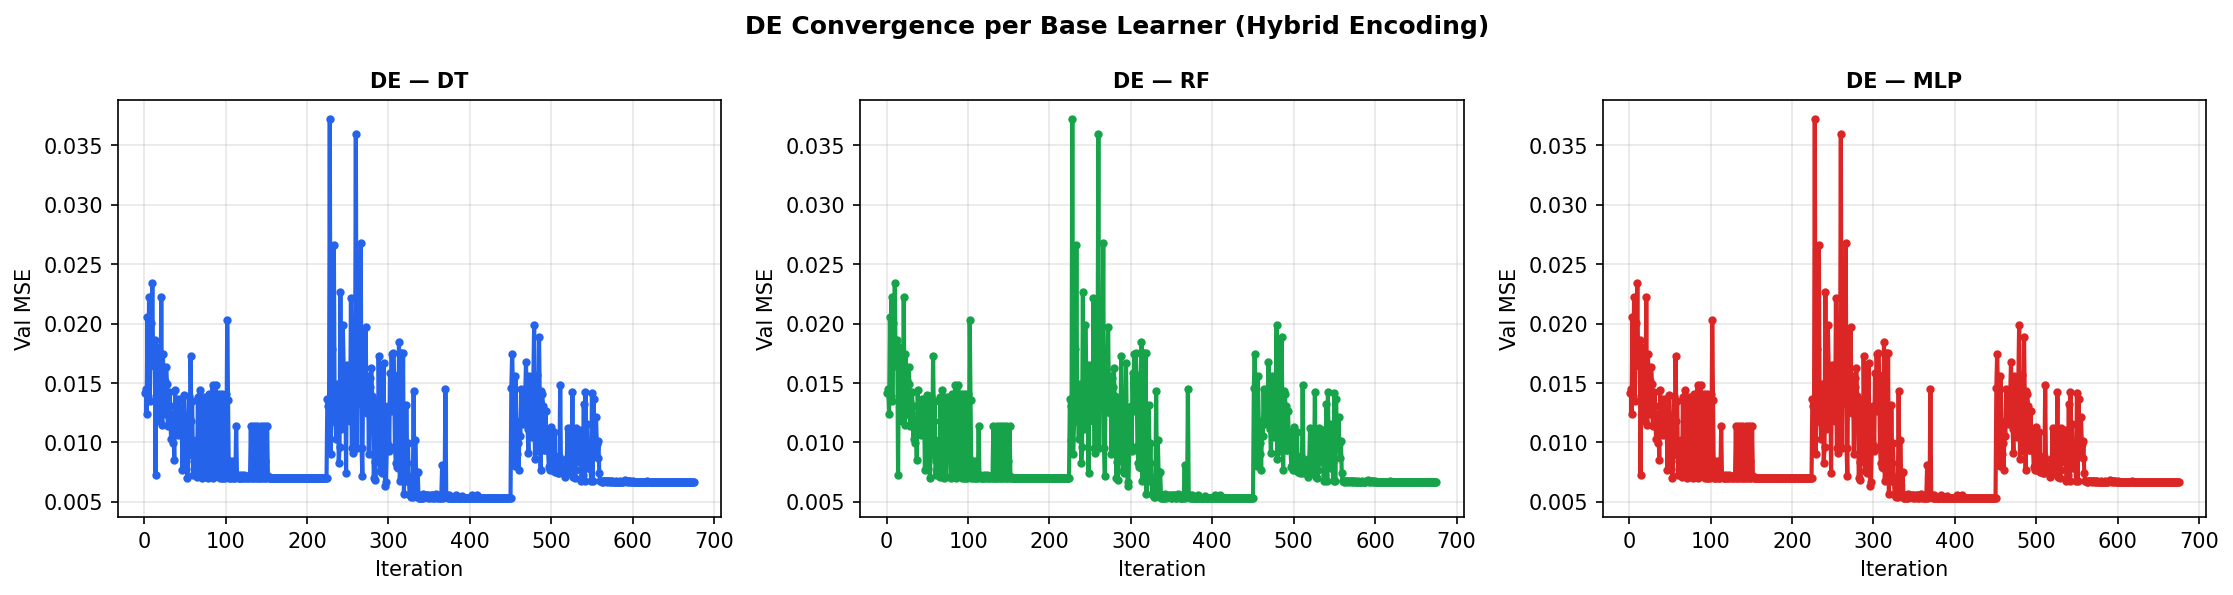

In [ ]:
# ── Cell 7 : DE Convergence Plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    hfile = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')
    if os.path.exists(hfile):
        hist = np.load(hfile)
        ax.plot(hist[:,0], hist[:,1], color=LEARNER_COLORS[clf_name], lw=2, marker='o', ms=3)
        ax.set_title(f'DE — {clf_name.upper()}', fontweight='bold', fontsize=10)
    else:
        ax.text(0.5, 0.5, f'{clf_name}: cache hit', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'{clf_name.upper()} — loaded', fontsize=10)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Val MSE'); ax.grid(True, alpha=0.3)
plt.suptitle('DE Convergence per Base Learner (Hybrid Encoding)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 8 : Quantum Feature Computation (train + val + test per learner) ────
qfeatures = {}
for clf_name, _ in BASE_LEARNERS:
    w  = best_weights[clf_name]
    ft = os.path.join(CACHE_DIR, f'X_train_q_{clf_name}_{HASH}.npy')
    fv = os.path.join(CACHE_DIR, f'X_val_q_{clf_name}_{HASH}.npy')
    fe = os.path.join(CACHE_DIR, f'X_test_q_{clf_name}_{HASH}.npy')
    if os.path.exists(ft) and os.path.exists(fv) and os.path.exists(fe):
        print(f'  [{clf_name}] Loading from cache.')
        qfeatures[clf_name] = {'train': np.load(ft), 'val': np.load(fv), 'test': np.load(fe)}
    else:
        print(f'  [{clf_name}] Computing quantum features...')
        Xq_tr = quantum_feature_map(X_train, w, circuit_default, verbose=True)
        Xq_vl = quantum_feature_map(X_val,   w, circuit_default, verbose=True)
        Xq_te = quantum_feature_map(X_test,  w, circuit_default, verbose=True)
        np.save(ft, Xq_tr); np.save(fv, Xq_vl); np.save(fe, Xq_te)
        qfeatures[clf_name] = {'train': Xq_tr, 'val': Xq_vl, 'test': Xq_te}

qfeatures_tv = {
    n: np.vstack([qfeatures[n]['train'], qfeatures[n]['val']]) for n, _ in BASE_LEARNERS
}
print('\nQuantum features ready.')

  [dt] Computing quantum features...
  917/9174
  1834/9174
  2751/9174
  3668/9174
  4585/9174
  5502/9174
  6419/9174
  7336/9174
  8253/9174
  9170/9174
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
  [rf] Computing quantum features...
  917/9174
  1834/9174
  2751/9174
  3668/9174
  4585/9174
  5502/9174
  6419/9174
  7336/9174
  8253/9174
  9170/9174
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  1372/1966
  1568/1966
  1764/1966
  1960/1966
  [mlp] Computing quantum features...
  917/9174
  1834/9174
  2751/9174
  3668/9174
  4585/9174
  5502/9174
  6419/9174
  7336/9174
  8253/9174
  9170/9174
  196/1966
  392/1966
  588/1966
  784/1966
  980/1966
  1176/1966
  13

In [ ]:
# ── Tune base learners on quantum training features (RandomizedSearchCV) ─────
print("\nTuning base learners on quantum training features...")
_Xq_dt  = qfeatures['dt']['train']
_Xq_rf  = qfeatures['rf']['train']
_Xq_mlp = qfeatures['mlp']['train']

tuned_dt  = tune_base_learner(DecisionTreeRegressor(random_state=SEED),
                               DT_PARAMS, _Xq_dt, Y_train, 'DT', DT_CACHE_BASE)
tuned_rf  = tune_base_learner(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                               RF_PARAMS, _Xq_rf, Y_train, 'RF', RF_CACHE_BASE)
tuned_mlp = tune_base_learner(
    Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor())]),
    MLP_PARAMS, _Xq_mlp, Y_train, 'MLP', MLP_CACHE_BASE)

tuned_base = {'dt': tuned_dt, 'rf': tuned_rf, 'mlp': tuned_mlp}
print("Base learner tuning complete.")




Tuning base learners on quantum training features...
  [DT] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [DT] Best params : {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10}
  [DT] Best CV MSE : 0.010124
  [RF] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [RF] Best params : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  [RF] Best CV MSE : 0.005998
  [MLP] Tuning with RandomizedSearchCV (20 iter, 5-fold)...
  [MLP] Best params : {'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__alpha': 0.01, 'mlp__activation': 'relu'}
  [MLP] Best CV MSE : 0.006266
Base learner tuning complete.


In [ ]:
# ── Cell 9 : Stacking — 5-Fold OOF Meta-Features ───────────────────────────
#
# FIX: OOF on (train+val) only — X_test never touched here.


kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
oof_preds = {n: np.zeros(len(Y_trainval)) for n, _ in BASE_LEARNERS}

print(f'Generating {N_SPLITS_CV}-fold OOF meta-features on X_trainval...')
for fold, (ti, vi) in enumerate(kf.split(X_trainval)):
    for clf_name, clf_template in BASE_LEARNERS:
        clf_fold = clone(tuned_base[clf_name])
        clf_fold.fit(qfeatures_tv[clf_name][ti], Y_trainval[ti])
        oof_preds[clf_name][vi] = clf_fold.predict(qfeatures_tv[clf_name][vi])
    print(f'  Fold {fold+1}/{N_SPLITS_CV} done.')

X_meta_train = np.column_stack([oof_preds[n] for n, _ in BASE_LEARNERS])
print(f'Meta-train shape: {X_meta_train.shape}  (columns: {[n for n,_ in BASE_LEARNERS]})')

Generating 5-fold OOF meta-features on X_trainval...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.
Meta-train shape: (11140, 3)  (columns: ['dt', 'rf', 'mlp'])


In [ ]:
# ── Cell 10 : Retrain Base Learners on Full X_trainval ─────────────────────
trained_base = {}
for clf_name, clf_template in BASE_LEARNERS:
    clf = clone(tuned_base[clf_name])
    clf.fit(qfeatures_tv[clf_name], Y_trainval)
    trained_base[clf_name] = clf
    print(f'  [{clf_name}] trained on {len(Y_trainval)} samples.')

X_meta_test = np.column_stack([
    trained_base[n].predict(qfeatures[n]['test']) for n, _ in BASE_LEARNERS
])
print(f'Meta-test shape: {X_meta_test.shape}')

  [dt] trained on 11140 samples.
  [rf] trained on 11140 samples.
  [mlp] trained on 11140 samples.
Meta-test shape: (1966, 3)


In [ ]:
# ── Cell 11 : GBM Meta-Learner (RandomizedSearchCV, cv=5) ─────────────────
GBM_CACHE = os.path.join(CACHE_DIR, 'meta_gbm.joblib')
GBM_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [2, 3, 4, 5],
    'subsample':         [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}
if os.path.exists(GBM_CACHE):
    meta_gbm = load(GBM_CACHE); print('GBM meta loaded from cache.')
else:
    print(f'Tuning GBM meta (RandomizedSearchCV, 30 iter, {N_SPLITS_CV}-fold)...')
    s = RandomizedSearchCV(GradientBoostingRegressor(random_state=SEED), GBM_PARAMS,
                            n_iter=30, scoring='neg_mean_squared_error',
                            cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0)
    s.fit(X_meta_train, Y_trainval)
    meta_gbm = s.best_estimator_
    dump(meta_gbm, GBM_CACHE)
    print(f'  Best: {s.best_params_}  |  CV MSE: {-s.best_score_:.4f}')

Tuning GBM meta (RandomizedSearchCV, 30 iter, 5-fold)...
  Best: {'subsample': 0.7, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 2, 'learning_rate': 0.05}  |  CV MSE: 0.0053


In [ ]:
# ── Cell 12 : RF Meta-Learner (RandomizedSearchCV, cv=5) ──────────────────
RF_META_CACHE = os.path.join(CACHE_DIR, 'meta_rf.joblib')
RF_META_PARAMS = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}
if os.path.exists(RF_META_CACHE):
    meta_rf = load(RF_META_CACHE); print('RF meta loaded from cache.')
else:
    print(f'Tuning RF meta (RandomizedSearchCV, 20 iter, {N_SPLITS_CV}-fold)...')
    s = RandomizedSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=-1), RF_META_PARAMS,
                            n_iter=20, scoring='neg_mean_squared_error',
                            cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0)
    s.fit(X_meta_train, Y_trainval)
    meta_rf = s.best_estimator_
    dump(meta_rf, RF_META_CACHE)
    print(f'  Best: {s.best_params_}  |  CV MSE: {-s.best_score_:.4f}')

Tuning RF meta (RandomizedSearchCV, 20 iter, 5-fold)...


/home/host1-vm4/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/sklea

  Best: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}  |  CV MSE: 0.0053


In [ ]:
# ── Cell 13 : Evaluation finale sur X_test (touché une seule fois) ─────────

def eval_model(model, X_te, Y_te, label, optimizer="—"):
    """Uniform evaluation: MSE, RMSE, MAE, R2, Pearson r, Spearman rho, Time, Memory."""
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)
    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    round(pr, 4),
        'Spearman rho': round(sr, 4),
        'Time (s)':     round(elapsed, 4),
        'Memory (MB)':  round(peak / 1024**2, 4),
        'Optimizer':    optimizer,
        '_pred':        Y_pred,
    }

# ── Appel de l'évaluation ────────────────────────────────────────────────────
print('Final evaluation on X_test (touched once):')
rows = []

for clf_name, _ in BASE_LEARNERS:
    r = eval_model(trained_base[clf_name], qfeatures[clf_name]['test'], Y_test,
                   label=f'Hybrid {clf_name.upper()} (base)', optimizer='COBYLA')
    rows.append(r)

res_gbm = eval_model(meta_gbm, X_meta_test, Y_test,
                     label='Stacking — GBM meta',
                     optimizer='RandomizedSearchCV (30 iter, 5-fold)')
res_rf  = eval_model(meta_rf,  X_meta_test, Y_test,
                     label='Stacking — RF meta',
                     optimizer='RandomizedSearchCV (20 iter, 5-fold)')
rows += [res_gbm, res_rf]

# ── Extraire les prédictions avant de les retirer du dict ───────────────────
preds      = {r['Model']: r.pop('_pred') for r in rows}
results_df = pd.DataFrame(rows).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho',
                'Time (s)', 'Memory (MB)', 'Optimizer']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())

Final evaluation on X_test (touched once):

── Test Set Results ──
                        MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)                             Optimizer
Model                                                                                                                                    
Hybrid DT (base)     0.0100  0.0998  0.0716  0.4794     0.7000        0.6252    0.0011       0.1237                                COBYLA
Hybrid RF (base)     0.0056  0.0749  0.0522  0.7066     0.8500        0.8271    0.2793       0.3929                                COBYLA
Hybrid MLP (base)    0.0065  0.0808  0.0569  0.6586     0.8144        0.7784    0.0090       3.0615                                COBYLA
Stacking — GBM meta  0.0052  0.0721  0.0500  0.7284     0.8542        0.8323    0.0165       0.0535  RandomizedSearchCV (30 iter, 5-fold)
Stacking — RF meta   0.0053  0.0725  0.0501  0.7252     0.8525        0.8307    0.2055       0.2972  Rand

In [ ]:
# ── Cell 14 : Wilcoxon Test (Stacking GBM vs Best Base) ────────────────────
r2_oof  = {n: r2_score(Y_trainval, oof_preds[n]) for n, _ in BASE_LEARNERS}
best_bn = max(r2_oof, key=r2_oof.get)
print(f'OOF R²: {r2_oof}  |  Best base: {best_bn}')

mse_stk, mse_base = [], []
for fold, (ti, vi) in enumerate(kf.split(X_meta_train)):
    mf = clone(meta_gbm); mf.fit(X_meta_train[ti], Y_trainval[ti])
    mse_stk.append(mean_squared_error(Y_trainval[vi], mf.predict(X_meta_train[vi])))
    mse_base.append(mean_squared_error(Y_trainval[vi], oof_preds[best_bn][vi]))

stat, p_val = wilcoxon(mse_base, mse_stk, alternative='greater')
print(f'\nWilcoxon (Stacking GBM vs {best_bn.upper()}): stat={stat:.3f}  p={p_val:.4f}  '
      f'{"significant" if p_val<0.05 else "not significant"}')

OOF R²: {'dt': 0.42959825246825956, 'rf': 0.669267520353978, 'mlp': 0.6496212144537838}  |  Best base: rf


In [ ]:
# ── Cell 15 : Publication Figures ───────────────────────────────────────
MODEL_COLORS = {
    'Hybrid DT (base)':    '#2563EB',
    'Hybrid RF (base)':    '#16A34A',
    'Hybrid MLP (base)':   '#D97706',
    'Stacking — GBM meta': '#7C3AED',
    'Stacking — RF meta':  '#DC2626'
}

# Figure 2: Pred vs actual — GBM stacking
y_gbm = preds['Stacking — GBM meta']
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=150)
lims = [min(Y_test.min(), y_gbm.min())-.3, max(Y_test.max(), y_gbm.max())+.3]
ax.scatter(Y_test, y_gbm, alpha=0.4, s=14, color='#7C3AED', edgecolors='none')
ax.plot(lims, lims, 'k--', lw=1); ax.set_xlim(lims); ax.set_ylim(lims)
r2v = results_df.loc['Stacking — GBM meta','R2']
prv = results_df.loc['Stacking — GBM meta','Pearson r']
ax.set_title(f'Stacking GBM\nR²={r2v:.4f}  r={prv:.4f}', fontsize=10)
ax.set_xlabel('Actual LN_IC50'); ax.set_ylabel('Predicted LN_IC50')
ax.grid(True, alpha=0.25); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: metrics bar all models
metrics_bar = ['MSE','MAE','R2','Pearson r','Spearman rho']
model_labels = results_df.index.tolist()
colors = [MODEL_COLORS.get(l,'#888') for l in model_labels]
fig, axes = plt.subplots(1, 5, figsize=(16, 4), dpi=150)
for ax, m in zip(axes, metrics_bar):
    vals = results_df[m].values
    bars = ax.bar(range(len(model_labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(model_labels)))
    ax.set_xticklabels([l.replace(' ','\n') for l in model_labels], fontsize=6)
    ax.set_title(m, fontweight='bold', fontsize=9); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003*abs(max(vals)-min(vals)),
                f'{val:.3f}', ha='center', va='bottom', fontsize=6)
plt.suptitle('Hybrid Ensemble (Amplitude+RX) — All Models Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: OOF scatter
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=150)
for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    pf = oof_preds[clf_name]
    r2v = r2_score(Y_trainval, pf)
    lm = [min(Y_trainval.min(), pf.min())-.3, max(Y_trainval.max(), pf.max())+.3]
    ax.scatter(Y_trainval, pf, alpha=0.3, s=8, color=LEARNER_COLORS[clf_name], edgecolors='none')
    ax.plot(lm, lm, 'k--', lw=1)
    ax.set_title(f'{clf_name.upper()} OOF | R²={r2v:.4f}', fontsize=10)
    ax.set_xlabel('Actual'); ax.set_ylabel('OOF Predicted'); ax.grid(True, alpha=0.25)
plt.suptitle(f'{N_SPLITS_CV}-Fold OOF — Base Learners', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_oof_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Figures: {os.path.abspath(FIGDIR)}')

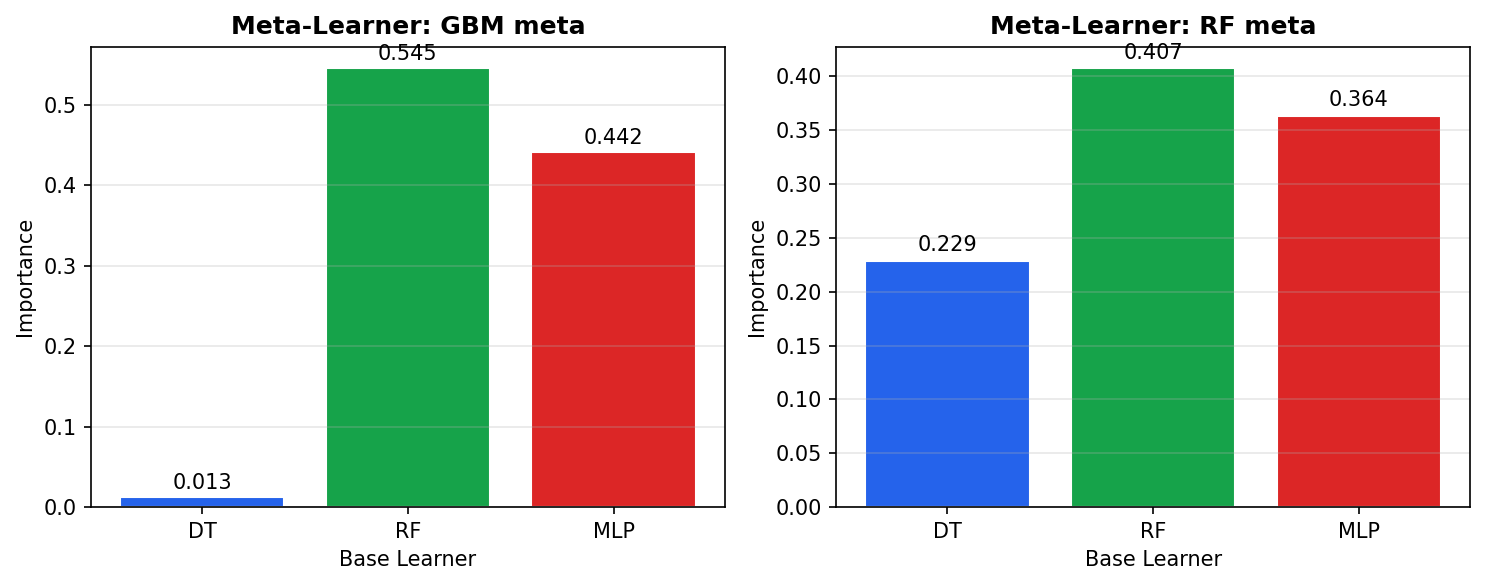

In [ ]:
# ── Cell 16 : Meta-Learner Feature Importance ─────────────────────────────
learner_names = [n.upper() for n, _ in BASE_LEARNERS]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
for ax, (mm, ml) in zip(axes, [(meta_gbm,'GBM meta'),(meta_rf,'RF meta')]):
    imp  = mm.feature_importances_
    bars = ax.bar(learner_names, imp,
                  color=[LEARNER_COLORS[n] for n,_ in BASE_LEARNERS], edgecolor='white')
    ax.set_xlabel('Base Learner'); ax.set_ylabel('Importance')
    ax.set_title(f'Meta-Learner: {ml}', fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, imp):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig5_meta_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


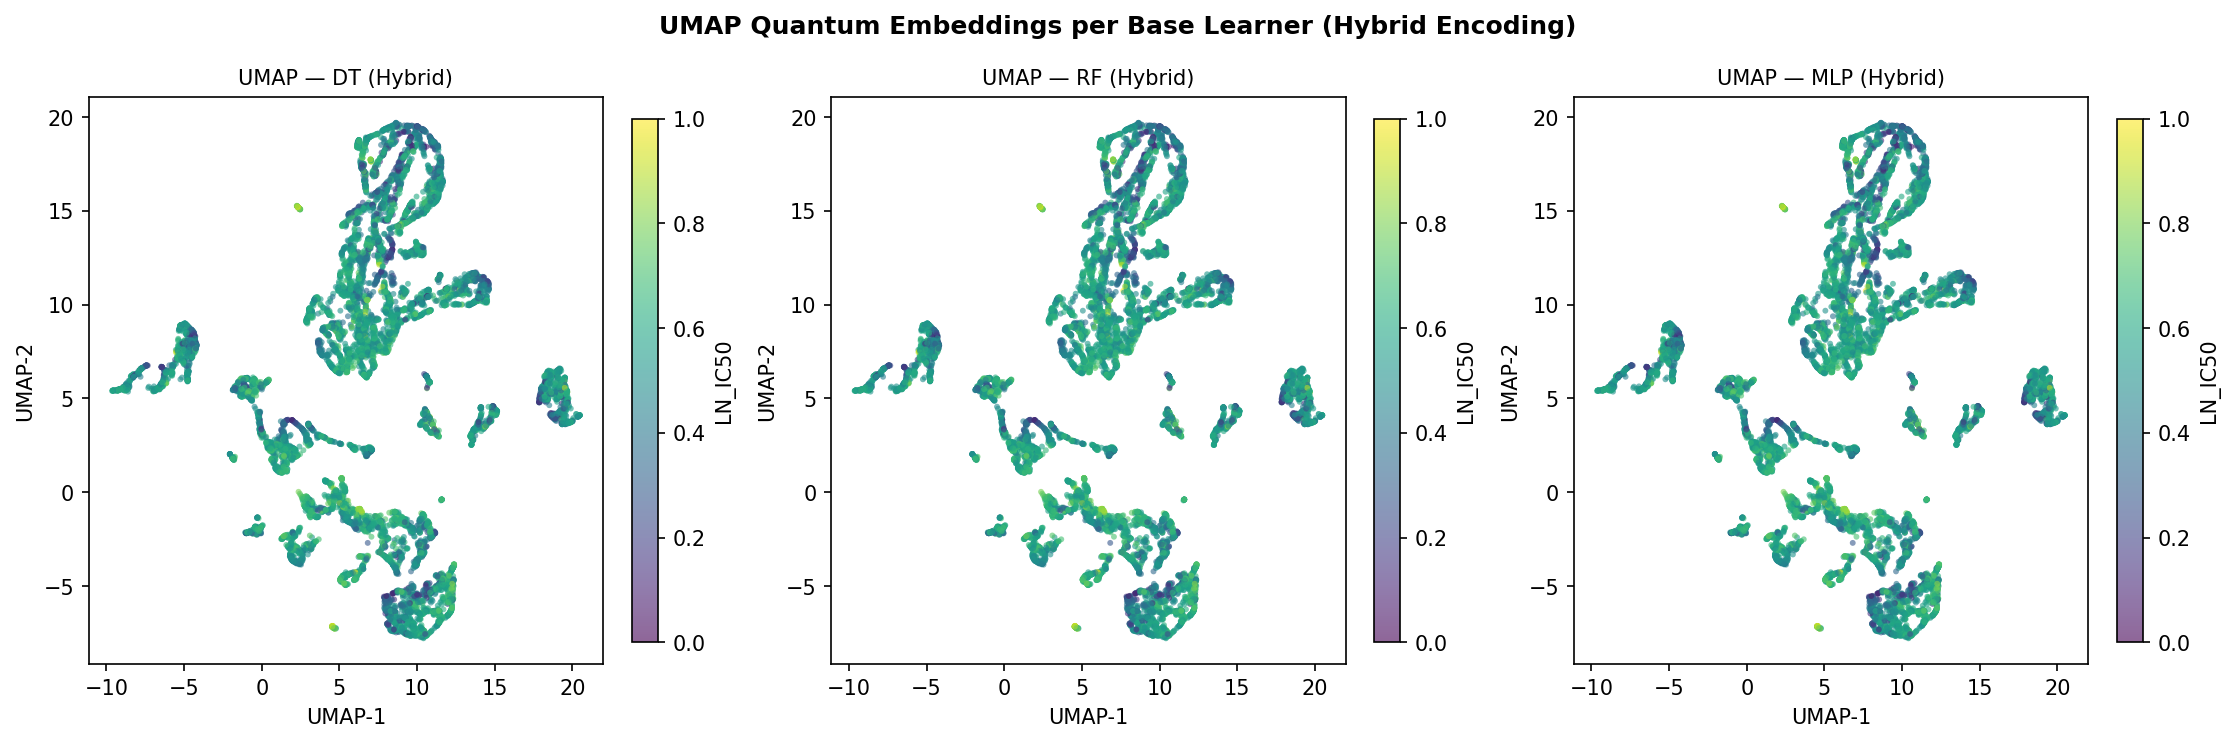

In [ ]:
# ── Cell 17 : UMAP per Base Learner ────────────────────────────────────
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
    for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
        X_2d = umap.UMAP(n_components=2, random_state=SEED).fit_transform(qfeatures_tv[clf_name])
        sc = ax.scatter(X_2d[:,0], X_2d[:,1], c=Y_trainval, cmap='viridis', s=8, alpha=0.6, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='LN_IC50', fraction=0.046)
        ax.set_title(f'UMAP — {clf_name.upper()} (Hybrid)', fontsize=10)
        ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.suptitle('UMAP Quantum Embeddings per Base Learner (Hybrid Encoding)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig6_umap.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('UMAP not available.')